   ES=F
   NQ=F
   RTY=F
   GC=F
   ZN=F

Usable symbols: ['ES=F', 'NQ=F', 'RTY=F', 'GC=F', 'ZN=F']
Usable ALT_SYMBOLS: ['NQ=F', 'RTY=F', 'GC=F', 'ZN=F']


C:\Users\Juanan\AppData\Local\Temp\ipykernel_21012\3522506654.py:415: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.




Strategy live start date: 2002-08-23

=== Per-asset weighted contribution summary ===
       total_contribution_sum_ret  total_active_contribution_vs_0  \
asset                                                               
ES=F                     1.918173                        1.918173   
NQ=F                     1.186601                        1.186601   
GC=F                     0.501268                        0.501268   
ZN=F                     0.005154                        0.005154   
RTY=F                   -0.019977                       -0.019977   

       total_return      cagr   ann_vol   sortino    max_dd  
asset                                                        
ES=F       4.012562  0.070618  0.160368  0.675942 -0.265392  
NQ=F       1.990144  0.047458  0.087667  0.773614 -0.177002  
GC=F       0.607983  0.020310  0.047033  0.606091 -0.149699  
ZN=F       0.003245  0.000137  0.012718  0.023097 -0.062924  
RTY=F     -0.023159 -0.000991  0.017089 -0.066505 -0.0743

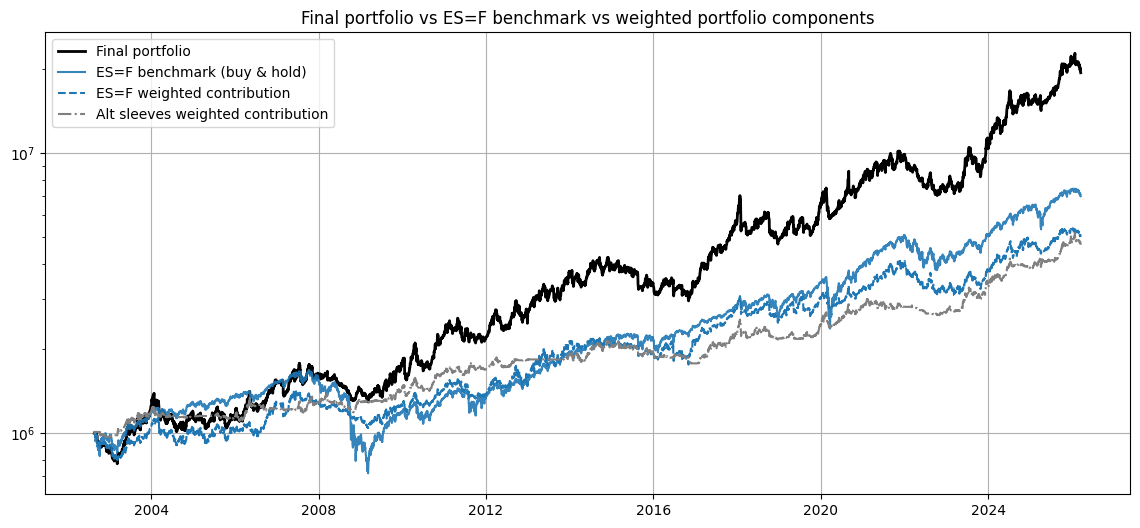

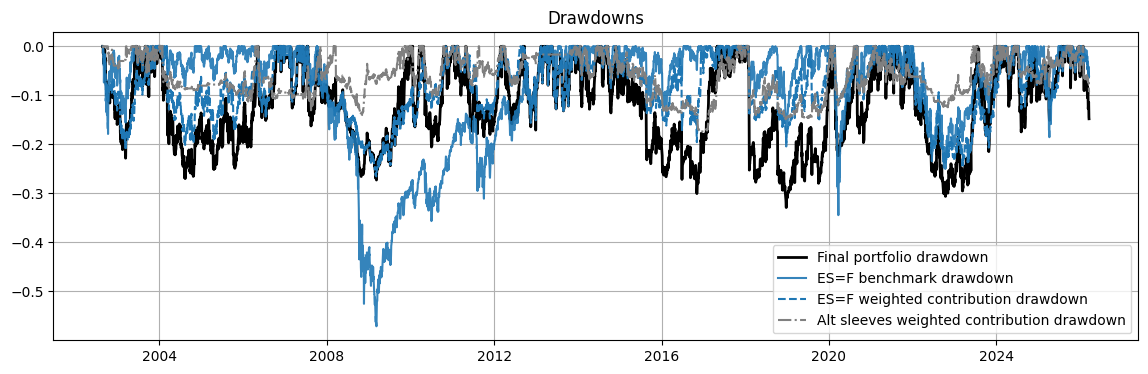

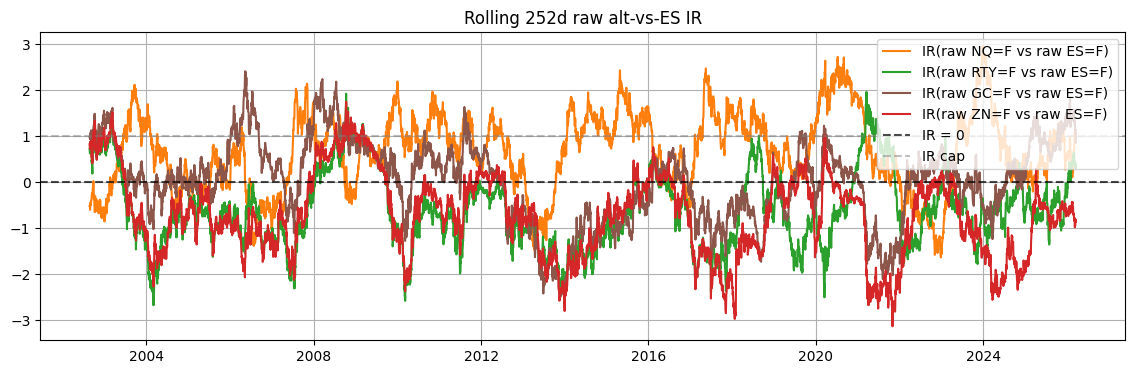

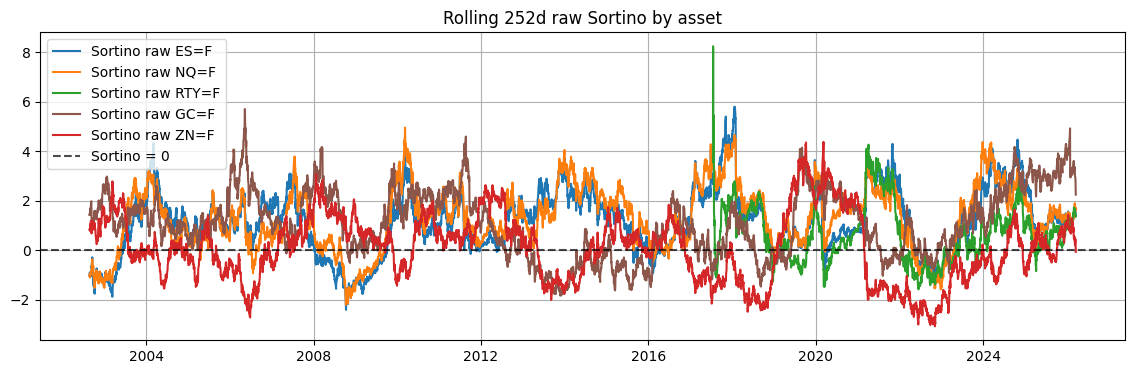

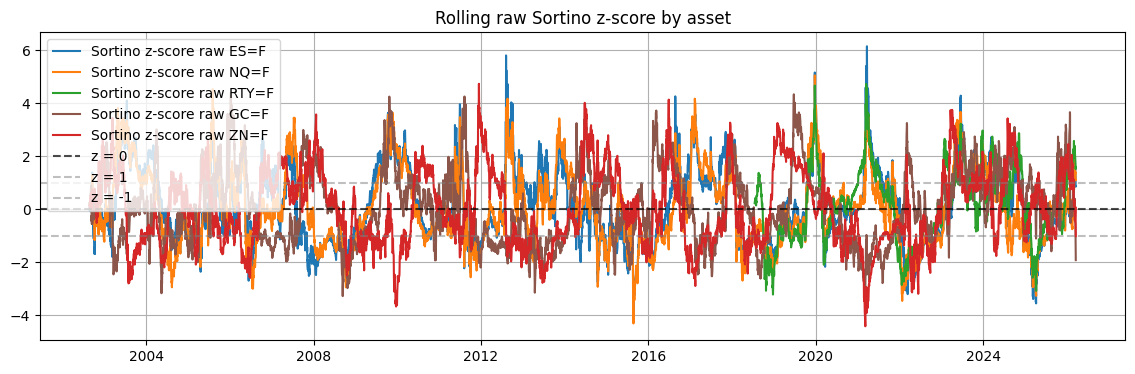

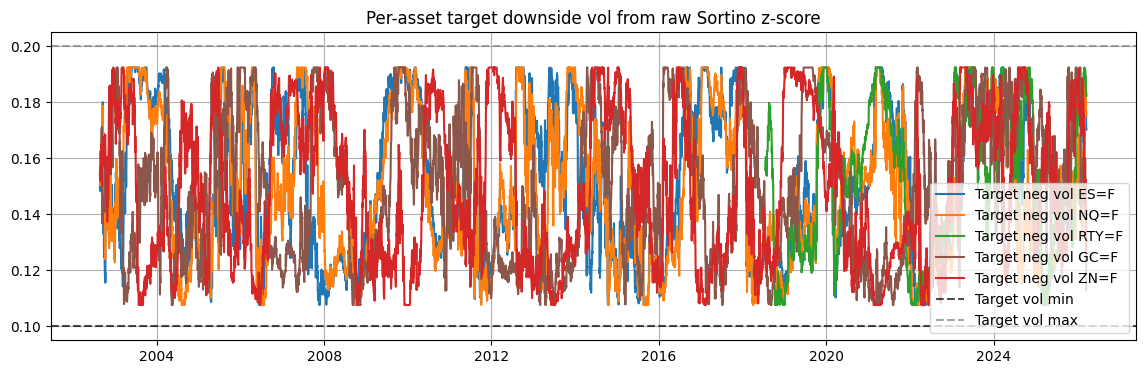

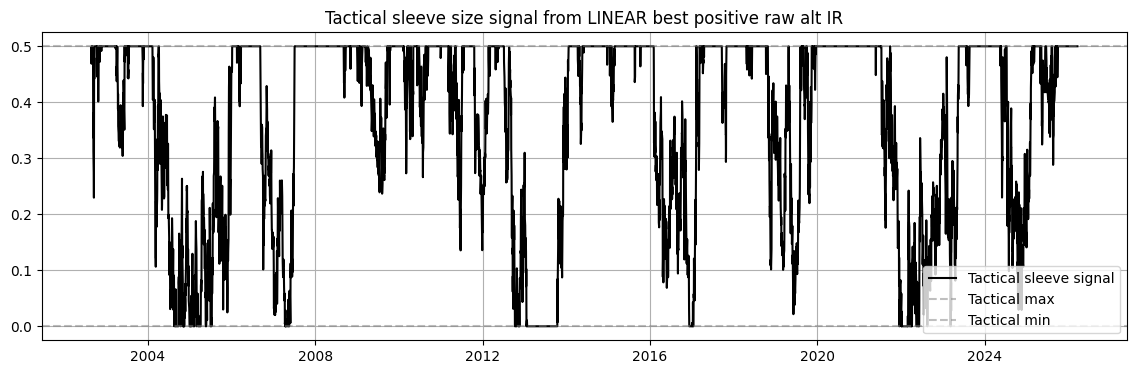

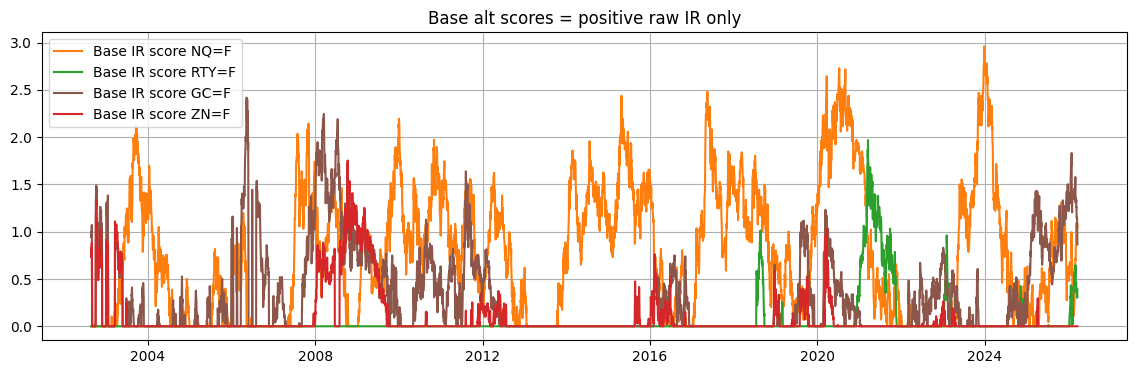

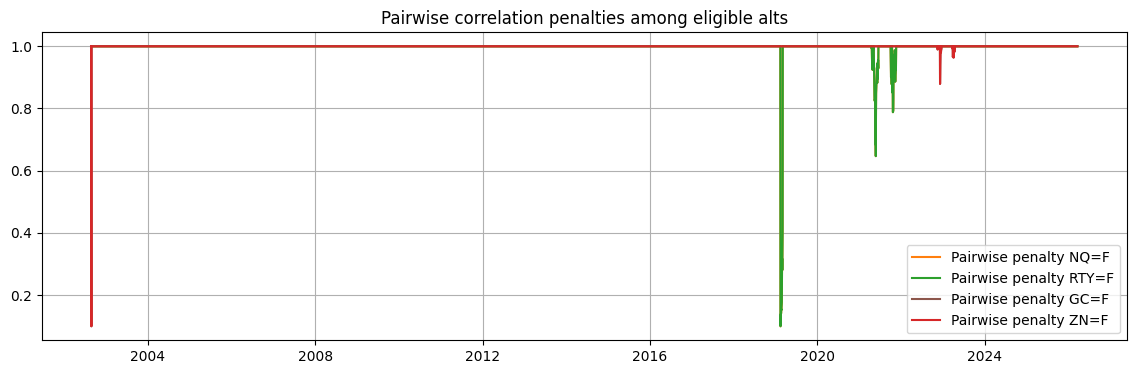

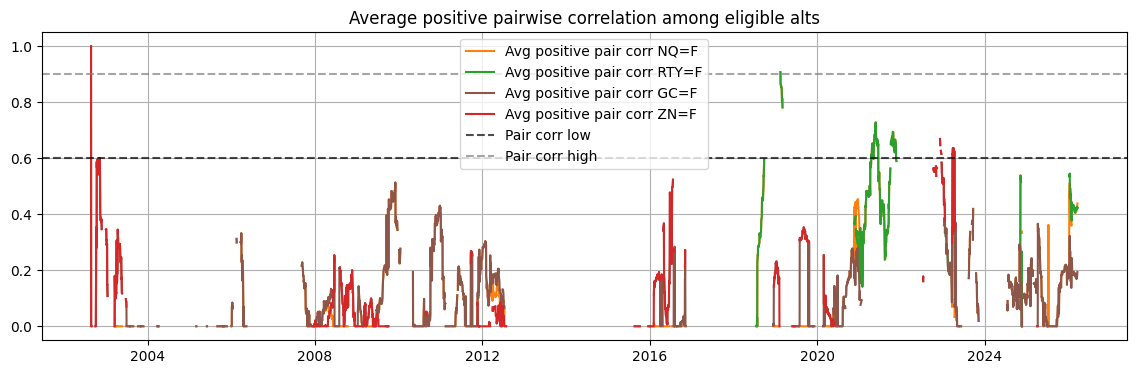

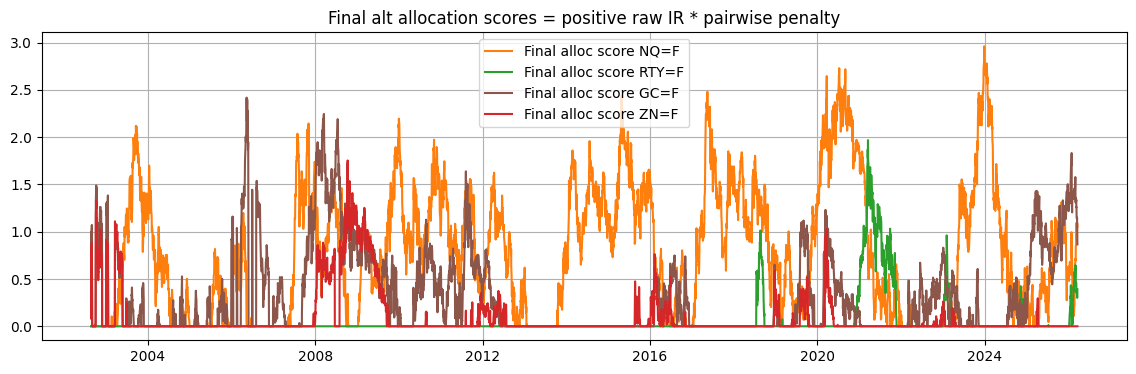

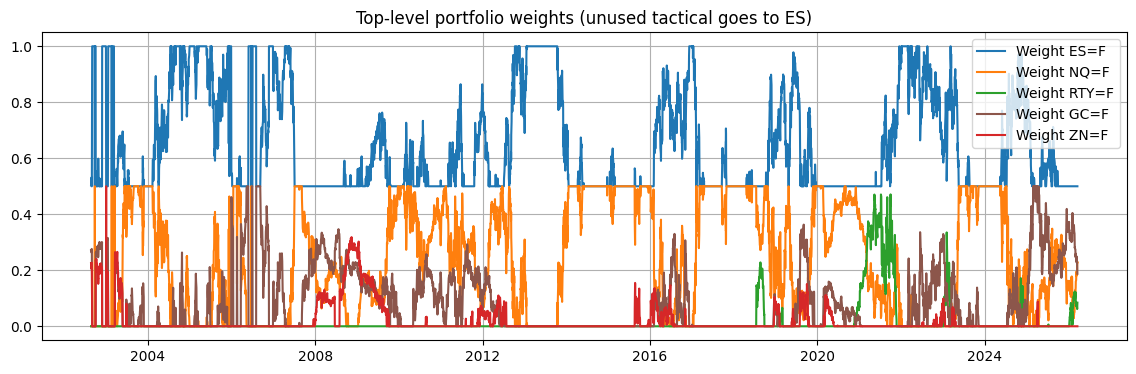

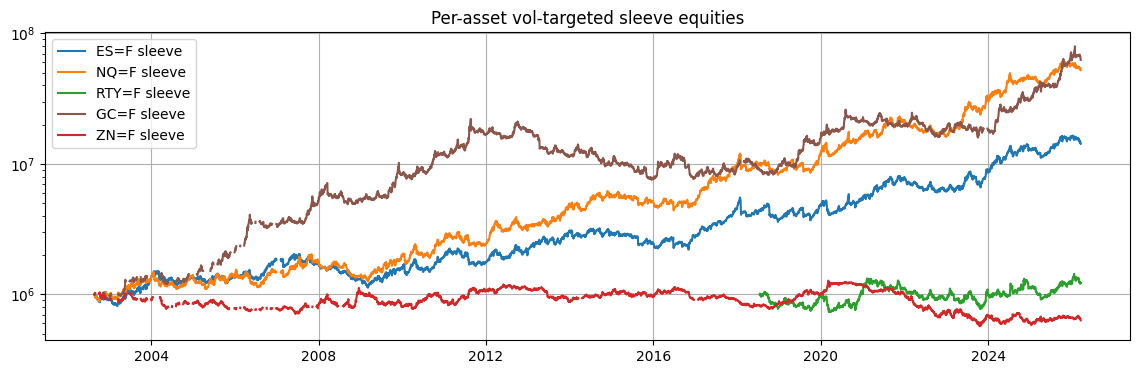

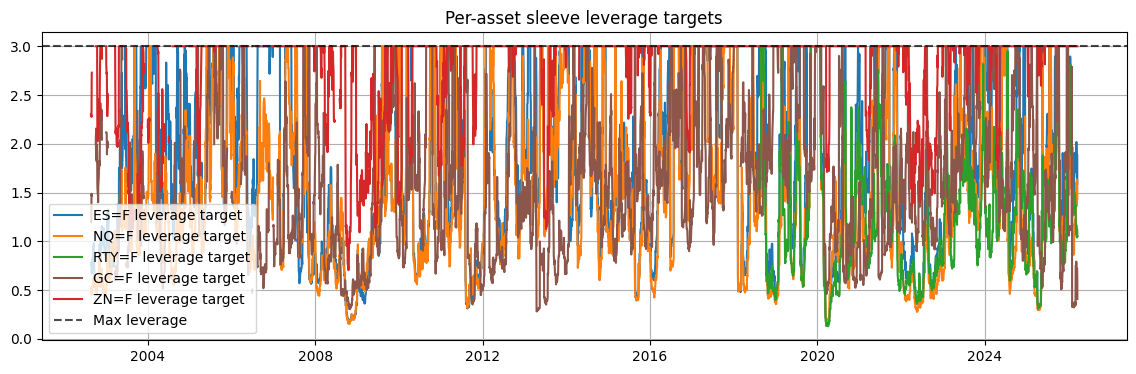

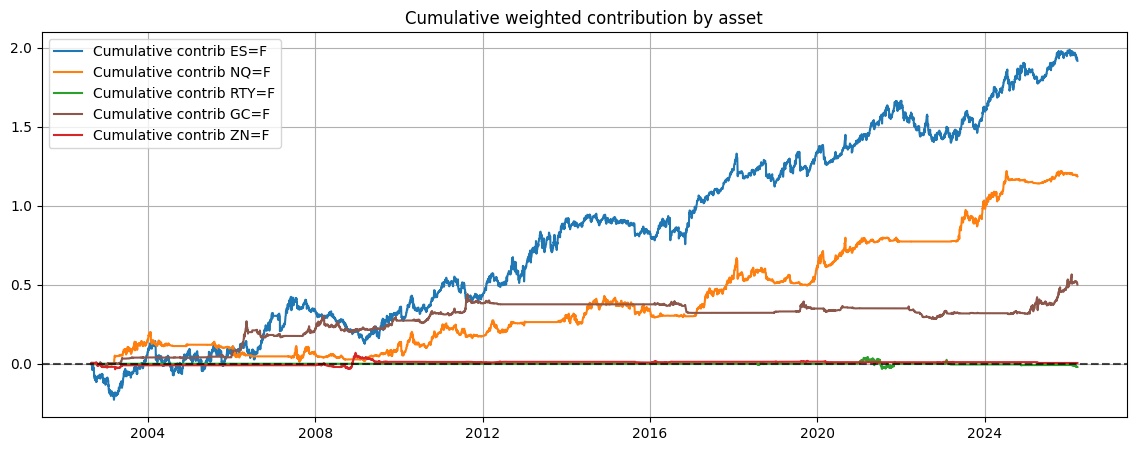

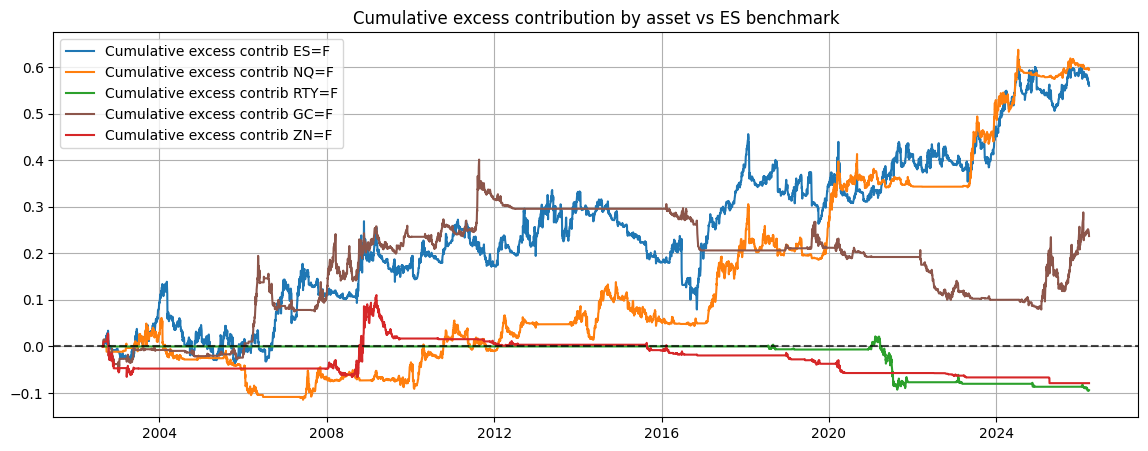

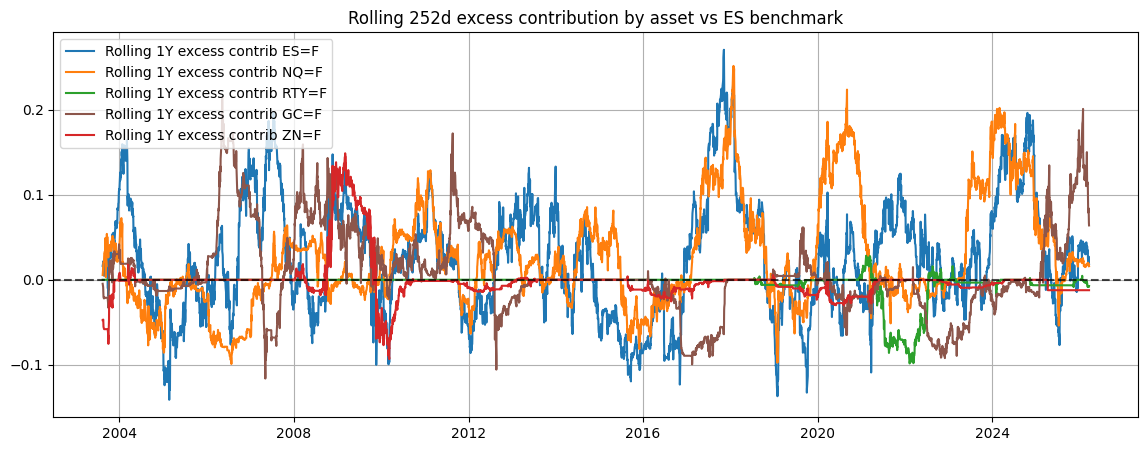

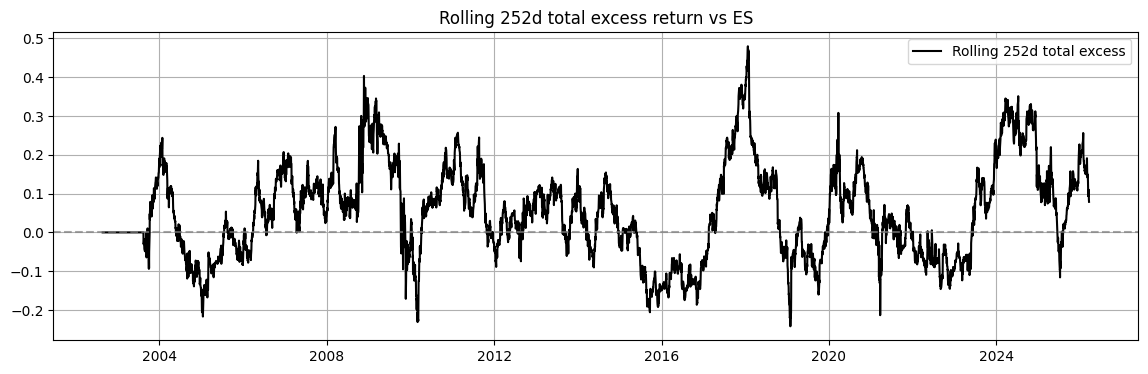

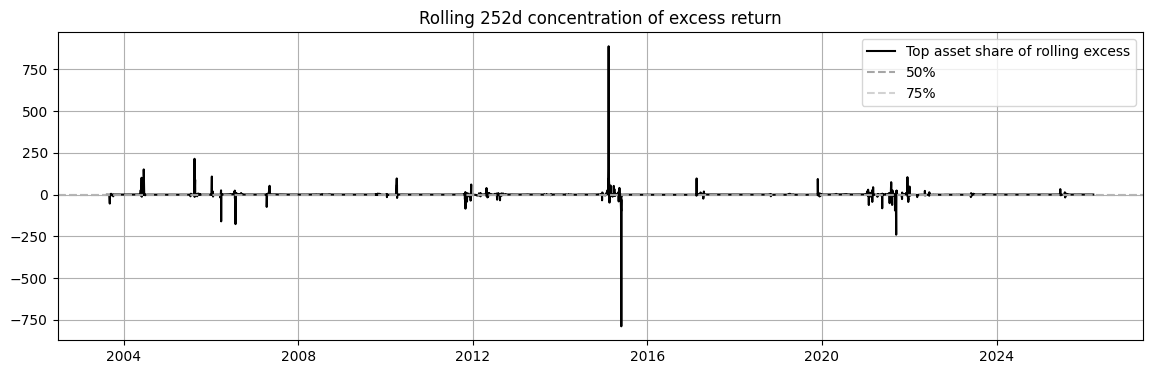

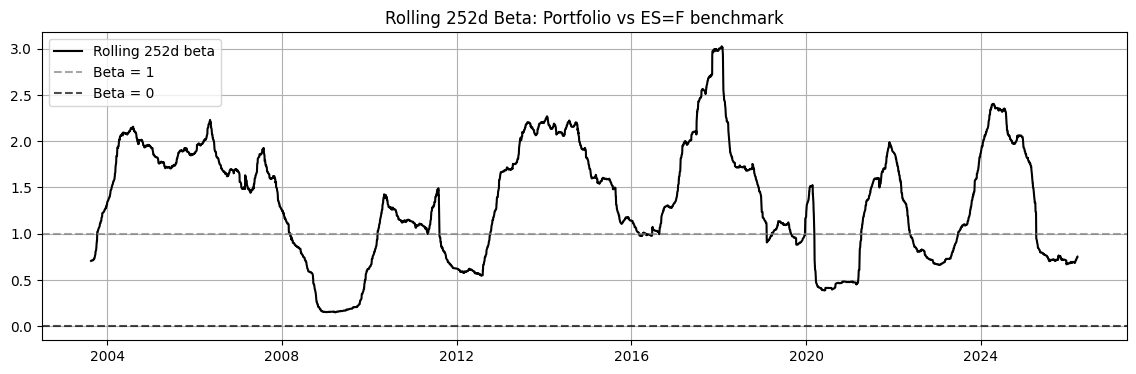

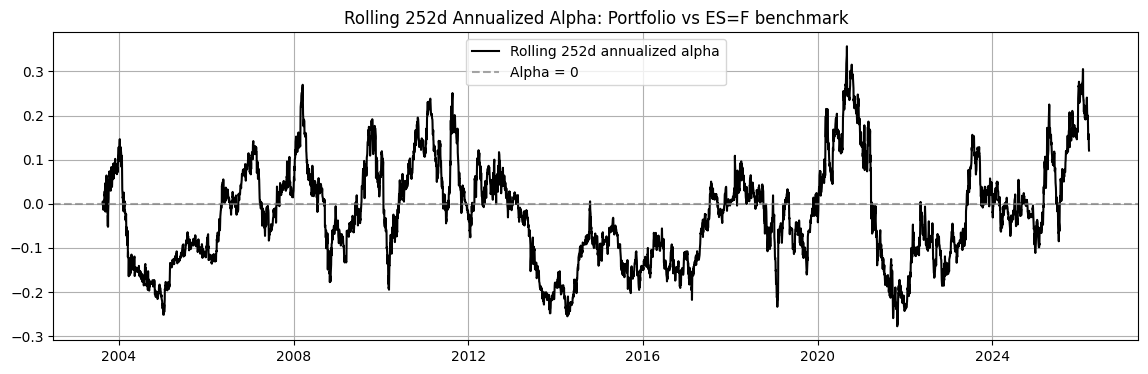

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

# =========================================================
# Equity Core + Tactical Sleeve Allocator (Design B)
#
# ARCHITECTURE
#   1) Core = ES only
#   2) Tactical sleeve contains all ALT_SYMBOLS
#   3) All Sortino and IR signals are computed from RAW returns only
#   4) Alt ranking uses IR(raw alt vs raw ES)
#   5) Tactical sleeve size uses best positive alt IR
#   6) Sleeves are only the implementation layer:
#        raw Sortino z-score -> target downside vol -> leverage
#   7) Pairwise correlation penalty among eligible alts
#   8) Any UNUSED tactical allocation goes back to ES
#   9) Tactical sleeve sizing is LINEAR from IR_FLOOR to IR_CAP
#  10) Plotting starts only when strategy is truly live
# =========================================================

# ================== Data source switch ==================
USE_YF = True  # set False to load from MT5 CSV/TSV

# ----- Requested analysis window -----
start = "2000-01-01"
end   = "2026-03-23"

# ----- Symbols -----
EQUITY_SYMBOL = "ES=F"
ALT_SYMBOLS = ['NQ=F', 'RTY=F', 'GC=F', 'ZN=F']

# Optional per-asset activation dates
ASSET_START_DATES = {
    "ES=F": "2000-01-01",
    "NQ=F": "2000-01-01",
    "RTY=F": "2000-01-01",
    "ZN=F": "2000-01-01",
    "ZT=F": "2000-01-01",
    "BTC=F": "2017-12-18",
    "GC=F": "2000-01-01",
    "SI=F": "2000-01-01",
    "YM=F": "2000-01-01",
    "ZF=F": "2000-01-01",
    "CL=F": "2000-01-01",
    "NG=F": "2000-01-01",
    "ZC=F": "2000-01-01",
    "ZS=F": "2000-01-01",
    "LE=F": "2000-01-01",
    "HE=F": "2000-01-01",
    "CC=F": "2000-01-01",
    "KC=F": "2000-01-01",
    "CT=F": "2000-01-01",
}

# ================== Consistent asset colors ==================
ASSET_COLORS = {
    "ES=F": "tab:blue",
    "NQ=F": "tab:orange",
    "RTY=F": "tab:green",
    "ZN=F": "tab:red",
    "ZT=F": "tab:cyan",
    "BTC=F": "tab:purple",
    "GC=F": "tab:brown",
    "SI=F": "tab:pink",
    "YM=F": "tab:olive",
    "ZF=F": "gold",
    "CL=F": "sienna",
    "NG=F": "deepskyblue",
    "ZC=F": "goldenrod",
    "ZS=F": "olive",
    "LE=F": "lightcoral",
    "HE=F": "hotpink",
    "CC=F": "chocolate",
    "KC=F": "peru",
    "CT=F": "slateblue",
}
PORTFOLIO_COLOR = "black"
ALT_BUCKET_COLOR = "gray"

# ================== Sleeve-level vol targeting inputs ==================
TARGET_NEG_VOL_MIN = 0.10
TARGET_NEG_VOL_MAX = 0.20

VOL_WINDOW = 21
SORTINO_WINDOW = 252

# Sortino z-score targeting
SORTINO_Z_WINDOW = 252
SORTINO_Z_CLIP   = 2.5
SORTINO_Z_CENTER = 0.0
SORTINO_Z_SCALE  = 1.0

RealizedVolFloor = 0.01
MAR = 0.0

MaxLeverage = 3.0
MinLeverage = 0.0
FlatEps     = 0.0

# ================== Allocator inputs ==================
IR_WINDOW = 252

# Tactical sleeve size from best positive alt IR(raw alt vs raw ES)
TACTICAL_MAX_WEIGHT = 0.50
TACTICAL_MIN_WEIGHT = 0.00

# LINEAR MAPPING:
#   IR <= IR_FLOOR -> tactical_score = 0
#   IR >= IR_CAP   -> tactical_score = 1
#   between them   -> linear ramp
IR_FLOOR = 0.0
IR_CAP   = 1.0

# Optional smoothing of top-level weights
SMOOTH_ALLOCATIONS   = False
ALLOC_SMOOTH_METHOD  = "ema"
ALLOC_SMOOTH_SPAN    = 10
ALLOC_SMOOTH_WINDOW  = 10

# ================== Pairwise correlation penalty ==================
PAIRWISE_CORR_WINDOW = 63
PAIRWISE_CORR_LOW  = 0.60
PAIRWISE_CORR_HIGH = 0.90
PAIRWISE_PENALTY_STRENGTH = 0.90

# ================== Rolling alpha/beta ==================
ROLLING_AB_WINDOW = 252
TRADING_DAYS = 252
MAR_EQ_RET = 0.0

# ================== Contribution analysis ==================
CONTRIB_ROLLING_WINDOW = 252

init_cash = 1_000_000.0


# =========================================================
# Helpers
# =========================================================
def make_index_tz_naive(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_convert(None)
    return df


def drawdown_from_equity(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0


def neg_annualized_vol_from_returns(rets: pd.Series, mar: float = 0.0, freq: int = 252) -> float:
    rets = rets.dropna()
    if len(rets) == 0:
        return float("nan")
    d = np.minimum(rets.to_numpy(dtype=float) - float(mar), 0.0)
    return float(np.sqrt(np.mean(d * d)) * np.sqrt(freq))


def perf_stats_from_equity(eq: pd.Series, freq: int = 252, mar_eq_ret: float = 0.0) -> dict:
    eq = eq.dropna()
    if len(eq) < 2:
        return {
            "total_return": np.nan,
            "cagr": np.nan,
            "ann_vol": np.nan,
            "neg_ann_vol": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "max_dd": np.nan
        }

    rets = eq.pct_change().dropna()
    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    years = (len(eq) - 1) / freq
    cagr = float((eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1.0) if years > 0 else np.nan

    ann_vol = float(rets.std(ddof=0) * np.sqrt(freq)) if len(rets) > 1 else np.nan
    neg_ann_vol = neg_annualized_vol_from_returns(rets, mar=mar_eq_ret, freq=freq)

    ann_ret = float(rets.mean() * freq) if len(rets) > 0 else np.nan
    sharpe = float(ann_ret / ann_vol) if ann_vol and ann_vol != 0 else np.nan
    sortino = float(ann_ret / neg_ann_vol) if neg_ann_vol and neg_ann_vol != 0 else np.nan
    max_dd = float(drawdown_from_equity(eq).min())

    return {
        "total_return": total_return,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "neg_ann_vol": neg_ann_vol,
        "sharpe": np.nan if ann_vol == 0 or pd.isna(ann_vol) else sharpe,
        "sortino": np.nan if neg_ann_vol == 0 or pd.isna(neg_ann_vol) else sortino,
        "max_dd": max_dd
    }


def downside_realized_vol(close_s: pd.Series, window: int, mar: float = 0.0,
                          floor: float = 0.0, ann_factor: float = 252.0) -> pd.Series:
    r = np.log(close_s / close_s.shift(1))
    d = np.minimum(r - mar, 0.0)
    rv_down = d.rolling(window, min_periods=window).apply(
        lambda x: np.sqrt(np.mean(np.square(x))), raw=True
    ) * np.sqrt(ann_factor)
    if floor is not None and floor > 0:
        rv_down = rv_down.clip(lower=floor)
    return rv_down


def rolling_sortino_from_returns(rets: pd.Series, window: int = 252, mar: float = 0.0,
                                 ann_factor: int = 252) -> pd.Series:
    rets = rets.astype(float)
    mu_ann = rets.rolling(window, min_periods=window).mean() * ann_factor
    downside = np.minimum(rets - mar, 0.0)
    down_vol_ann = downside.rolling(window, min_periods=window).apply(
        lambda x: np.sqrt(np.mean(np.square(x))), raw=True
    ) * np.sqrt(ann_factor)
    return mu_ann / down_vol_ann.replace(0.0, np.nan)


def rolling_zscore(s: pd.Series, window: int) -> pd.Series:
    mu = s.rolling(window, min_periods=window).mean()
    sd = s.rolling(window, min_periods=window).std(ddof=0)
    return (s - mu) / sd.replace(0.0, np.nan)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def map_zscore_to_target_vol(z: pd.Series,
                             vol_low: float,
                             vol_high: float,
                             center: float = 0.0,
                             scale: float = 1.0,
                             z_clip: float = 3.0) -> pd.Series:
    zc = z.clip(lower=-z_clip, upper=z_clip)
    score = sigmoid((zc - center) / scale)
    return vol_low + (vol_high - vol_low) * score


def smooth_series(s: pd.Series, method: str = "ema", span: int = 10, window: int = 10) -> pd.Series:
    if method.lower() == "ema":
        return s.ewm(span=span, adjust=False, min_periods=1).mean()
    if method.lower() == "sma":
        return s.rolling(window=window, min_periods=1).mean()
    raise ValueError(f"Unknown smoothing method: {method}")


def rolling_information_ratio(active_ret: pd.Series, window: int = 252) -> pd.Series:
    mu = active_ret.rolling(window, min_periods=window).mean()
    sd = active_ret.rolling(window, min_periods=window).std(ddof=0)
    ir = mu / sd.replace(0.0, np.nan)
    return ir * np.sqrt(TRADING_DAYS)


def rolling_alpha_beta(strat_ret: pd.Series, bench_ret: pd.Series, window: int = 252, ann_factor: int = 252):
    df_ab = pd.concat([strat_ret.rename("S"), bench_ret.rename("B")], axis=1).dropna()
    if df_ab.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    S = df_ab["S"]
    B = df_ab["B"]

    meanS = S.rolling(window, min_periods=window).mean()
    meanB = B.rolling(window, min_periods=window).mean()
    covSB = S.rolling(window, min_periods=window).cov(B)
    varB  = B.rolling(window, min_periods=window).var()

    beta = covSB / varB.replace(0.0, np.nan)
    alpha_ann = (meanS - beta * meanB) * ann_factor

    return beta.reindex(strat_ret.index), alpha_ann.reindex(strat_ret.index)


def corr_penalty_from_avg_corr(avg_corr: float,
                               corr_low: float,
                               corr_high: float,
                               penalty_strength: float) -> float:
    if pd.isna(avg_corr):
        return 1.0
    if avg_corr <= corr_low:
        return 1.0
    if avg_corr >= corr_high:
        return 1.0 - penalty_strength

    x = (avg_corr - corr_low) / (corr_high - corr_low)
    x = float(np.clip(x, 0.0, 1.0))
    s = 3.0 * x**2 - 2.0 * x**3
    return 1.0 - penalty_strength * s


def contribution_summary_from_returns(contrib_ret_df: pd.DataFrame,
                                      benchmark_ret: pd.Series,
                                      label_prefix: str = "") -> pd.DataFrame:
    rows = []
    for col in contrib_ret_df.columns:
        eq = init_cash * (1.0 + contrib_ret_df[col].fillna(0.0)).cumprod()
        stats = perf_stats_from_equity(eq, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET)
        total_contrib = float(contrib_ret_df[col].sum())
        active_contrib = float((contrib_ret_df[col] - 0.0).sum())
        rows.append({
            "asset": col,
            "total_contribution_sum_ret": total_contrib,
            "total_active_contribution_vs_0": active_contrib,
            "total_return": stats["total_return"],
            "cagr": stats["cagr"],
            "ann_vol": stats["ann_vol"],
            "sortino": stats["sortino"],
            "max_dd": stats["max_dd"]
        })
    out = pd.DataFrame(rows).set_index("asset").sort_values("total_contribution_sum_ret", ascending=False)
    if label_prefix:
        out = out.add_prefix(label_prefix)
    return out


def normalize_positive_shares(s: pd.Series) -> pd.Series:
    s = s.clip(lower=0.0)
    denom = s.sum()
    if denom <= 0:
        return pd.Series(0.0, index=s.index)
    return s / denom


# =========================================================
# Data loading
# =========================================================
all_symbols = list(dict.fromkeys([EQUITY_SYMBOL] + ALT_SYMBOLS))

for sym in all_symbols:
    if not isinstance(sym, str) or not sym.strip():
        raise ValueError(f"Invalid symbol in all_symbols: {repr(sym)}")

requested_start_ts = pd.to_datetime(start)
requested_end_ts   = pd.to_datetime(end)

max_warmup = max(VOL_WINDOW, SORTINO_WINDOW, SORTINO_Z_WINDOW, IR_WINDOW, ROLLING_AB_WINDOW, PAIRWISE_CORR_WINDOW)
if SMOOTH_ALLOCATIONS:
    max_warmup += max(ALLOC_SMOOTH_SPAN, ALLOC_SMOOTH_WINDOW)

warmup_buffer_days = max_warmup + 10
warmup_start_ts = requested_start_ts - pd.offsets.BDay(warmup_buffer_days)

if not USE_YF:
    raise ValueError("USE_YF=False multi-asset mode is not implemented in this script.")

price_dict = {}
failed_symbols = []

print("Downloading symbols:")
for sym in all_symbols:
    print("  ", sym)
    try:
        data = vbt.YFData.download(
            sym,
            start=warmup_start_ts.strftime("%Y-%m-%d"),
            end=end
        )
        df_sym = data.get()
        df_sym = df_sym.rename(columns={c: c.capitalize() for c in df_sym.columns})

        if df_sym is None or df_sym.empty:
            raise ValueError(f"No data returned for {sym}")

        if "Close" not in df_sym.columns:
            raise ValueError(f"YF data missing Close for {sym}. Columns: {df_sym.columns.tolist()}")

        df_sym = df_sym[["Close"]].copy()
        df_sym.index = pd.to_datetime(df_sym.index)
        df_sym = make_index_tz_naive(df_sym)
        df_sym.index = df_sym.index.normalize()

        if df_sym["Close"].dropna().empty:
            raise ValueError(f"Close series empty for {sym}")

        price_dict[sym] = df_sym["Close"].astype(float)

    except Exception as e:
        print(f"[FAILED] {sym}: {type(e).__name__}: {e}")
        failed_symbols.append(sym)

if failed_symbols:
    print("\nFailed symbols:")
    for sym in failed_symbols:
        print("  ", sym)

if EQUITY_SYMBOL in failed_symbols:
    raise ValueError(f"EQUITY_SYMBOL failed to download: {EQUITY_SYMBOL}")

ALT_SYMBOLS = [sym for sym in ALT_SYMBOLS if sym in price_dict]
if len(ALT_SYMBOLS) == 0:
    raise ValueError("No ALT_SYMBOLS left after download failures.")

all_symbols = list(dict.fromkeys([EQUITY_SYMBOL] + ALT_SYMBOLS))
print("\nUsable symbols:", all_symbols)
print("Usable ALT_SYMBOLS:", ALT_SYMBOLS)

close_df = pd.concat({sym: price_dict[sym] for sym in all_symbols}, axis=1).sort_index()
close_df = close_df.loc[warmup_start_ts:requested_end_ts].copy()
close_df = close_df.loc[close_df.index.dayofweek < 5].copy()

dates = close_df.index

if len(close_df) < max_warmup + 3:
    raise ValueError(
        f"Not enough total rows after warmup. Need at least {max_warmup + 3} rows, got {len(close_df)}."
    )

# =========================================================
# Raw returns and raw-signal layer
# =========================================================
raw_returns_df = close_df.pct_change().fillna(0.0)
raw_benchmark_ret = raw_returns_df[EQUITY_SYMBOL].copy()

raw_sortino = {}
raw_sortino_z = {}
for sym in all_symbols:
    srt = rolling_sortino_from_returns(
        rets=raw_returns_df[sym],
        window=SORTINO_WINDOW,
        mar=MAR,
        ann_factor=TRADING_DAYS
    )
    raw_sortino[sym] = srt
    raw_sortino_z[sym] = rolling_zscore(srt, SORTINO_Z_WINDOW)

raw_sortino_df = pd.DataFrame(raw_sortino).reindex(dates)
raw_sortino_z_df = pd.DataFrame(raw_sortino_z).reindex(dates)

alt_ir_vs_es = {}
for alt in ALT_SYMBOLS:
    alt_ir_vs_es[alt] = rolling_information_ratio(
        raw_returns_df[alt] - raw_benchmark_ret,
        window=IR_WINDOW
    )

alt_ir_vs_es_df = pd.DataFrame(alt_ir_vs_es).reindex(dates)

# =========================================================
# Sleeve implementation layer
# =========================================================
asset_sleeve_equity = {}
asset_sleeve_returns = {}
asset_target_vol = {}
asset_L_star = {}
asset_L_star_raw = {}
asset_live_mask = {}

for sym in all_symbols:
    close_s = close_df[sym].astype(float)
    start_dt = pd.to_datetime(ASSET_START_DATES.get(sym, start))
    asset_ret = raw_returns_df[sym].copy()

    rv_down = downside_realized_vol(
        close_s=close_s,
        window=VOL_WINDOW,
        mar=MAR,
        floor=RealizedVolFloor,
        ann_factor=TRADING_DAYS
    )
    rv1 = rv_down.shift(1)

    target_vol = map_zscore_to_target_vol(
        z=raw_sortino_z_df[sym],
        vol_low=TARGET_NEG_VOL_MIN,
        vol_high=TARGET_NEG_VOL_MAX,
        center=SORTINO_Z_CENTER,
        scale=SORTINO_Z_SCALE,
        z_clip=SORTINO_Z_CLIP
    )
    asset_target_vol[sym] = target_vol

    L_star_raw = (target_vol / rv1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    L_star = L_star_raw.clip(lower=MinLeverage, upper=MaxLeverage)
    if FlatEps > 0:
        L_star = L_star.where(L_star >= FlatEps, 0.0)

    live_mask = (
        (close_s.index >= start_dt)
        & rv1.notna()
        & target_vol.notna()
        & close_s.notna()
    )
    asset_live_mask[sym] = live_mask

    L_star = L_star.where(live_mask, 0.0)
    L_star_raw = L_star_raw.where(live_mask, 0.0)

    asset_L_star_raw[sym] = L_star_raw
    asset_L_star[sym] = L_star

    sleeve_ret = (L_star.shift(1).fillna(0.0) * asset_ret.fillna(0.0)).fillna(0.0)
    sleeve_eq = init_cash * (1.0 + sleeve_ret).cumprod()

    asset_sleeve_returns[sym] = sleeve_ret
    asset_sleeve_equity[sym] = sleeve_eq

asset_sleeve_returns_df = pd.DataFrame(asset_sleeve_returns).reindex(dates).fillna(0.0)
asset_sleeve_equity_df = pd.DataFrame(asset_sleeve_equity).reindex(dates).ffill()
asset_target_vol_df = pd.DataFrame(asset_target_vol).reindex(dates)

# Buy-and-hold ES benchmark for comparison
benchmark_equity = init_cash * (1.0 + raw_benchmark_ret).cumprod()

# =========================================================
# Allocation layer
# =========================================================
positive_alt_ir_df = alt_ir_vs_es_df.clip(lower=0.0)
best_alt_ir = positive_alt_ir_df.max(axis=1).fillna(0.0)

# LINEAR tactical sleeve sizing
if IR_CAP <= IR_FLOOR:
    raise ValueError("IR_CAP must be strictly greater than IR_FLOOR for linear tactical sizing.")

tactical_score = ((best_alt_ir - IR_FLOOR) / (IR_CAP - IR_FLOOR)).clip(lower=0.0, upper=1.0)

tactical_weight_used = (
    TACTICAL_MIN_WEIGHT
    + (TACTICAL_MAX_WEIGHT - TACTICAL_MIN_WEIGHT) * tactical_score
).fillna(TACTICAL_MIN_WEIGHT)

base_score_df = positive_alt_ir_df.copy()
for alt in ALT_SYMBOLS:
    live_and_signal = asset_live_mask[alt] & alt_ir_vs_es_df[alt].notna()
    base_score_df.loc[~live_and_signal, alt] = 0.0

# Pairwise diversification penalty on sleeve returns
alt_returns_df = asset_sleeve_returns_df[ALT_SYMBOLS].copy()

pair_corr = {}
for i in ALT_SYMBOLS:
    for j in ALT_SYMBOLS:
        if i == j:
            continue
        pair_corr[(i, j)] = alt_returns_df[i].rolling(
            PAIRWISE_CORR_WINDOW,
            min_periods=PAIRWISE_CORR_WINDOW
        ).corr(alt_returns_df[j])

pairwise_avg_corr_df = pd.DataFrame(np.nan, index=dates, columns=ALT_SYMBOLS)
pairwise_penalty_df = pd.DataFrame(1.0, index=dates, columns=ALT_SYMBOLS)

for dt in dates:
    eligible = [alt for alt in ALT_SYMBOLS if base_score_df.loc[dt, alt] > 0.0]

    if len(eligible) <= 1:
        for alt in eligible:
            pairwise_penalty_df.loc[dt, alt] = 1.0
        continue

    for alt in eligible:
        others = [o for o in eligible if o != alt]
        corr_vals = []
        for other in others:
            c = pair_corr[(alt, other)].loc[dt]
            if pd.notna(c):
                corr_vals.append(max(float(c), 0.0))

        avg_pos_corr = np.nan if len(corr_vals) == 0 else float(np.mean(corr_vals))
        pairwise_avg_corr_df.loc[dt, alt] = avg_pos_corr
        pairwise_penalty_df.loc[dt, alt] = corr_penalty_from_avg_corr(
            avg_corr=avg_pos_corr,
            corr_low=PAIRWISE_CORR_LOW,
            corr_high=PAIRWISE_CORR_HIGH,
            penalty_strength=PAIRWISE_PENALTY_STRENGTH
        )

alloc_score_df = base_score_df * pairwise_penalty_df

for alt in ALT_SYMBOLS:
    live_and_signal = asset_live_mask[alt] & alt_ir_vs_es_df[alt].notna()
    alloc_score_df.loc[~live_and_signal, alt] = 0.0
    pairwise_penalty_df.loc[~live_and_signal, alt] = 1.0
    pairwise_avg_corr_df.loc[~live_and_signal, alt] = np.nan

score_sum = alloc_score_df.sum(axis=1)
alt_weights = pd.DataFrame(0.0, index=dates, columns=ALT_SYMBOLS)

has_positive_score = score_sum > 0.0
for alt in ALT_SYMBOLS:
    alt_weights.loc[has_positive_score, alt] = (
        tactical_weight_used.loc[has_positive_score]
        * alloc_score_df.loc[has_positive_score, alt]
        / score_sum.loc[has_positive_score]
    )

alt_weights = alt_weights.fillna(0.0)

# ES gets whatever is NOT actually allocated to alts
weights_df = pd.concat(
    [
        (1.0 - alt_weights.sum(axis=1)).rename(EQUITY_SYMBOL),
        alt_weights
    ],
    axis=1
).fillna(0.0)

if SMOOTH_ALLOCATIONS:
    for col in weights_df.columns:
        weights_df[col] = smooth_series(
            weights_df[col],
            method=ALLOC_SMOOTH_METHOD,
            span=ALLOC_SMOOTH_SPAN,
            window=ALLOC_SMOOTH_WINDOW
        )
    weights_sum = weights_df.sum(axis=1).replace(0.0, np.nan)
    weights_df = weights_df.div(weights_sum, axis=0).fillna(0.0)

# Diagnostics
core_es_weight_actual = weights_df[EQUITY_SYMBOL].copy()
weight_total_alts_actual = weights_df[ALT_SYMBOLS].sum(axis=1)

# =========================================================
# Final portfolio from sleeves
# =========================================================
weights_t1 = weights_df.shift(1).fillna(0.0)

# Per-asset weighted contributions to portfolio returns
weighted_contrib_ret_df = weights_t1 * asset_sleeve_returns_df[weights_df.columns]
portfolio_ret = weighted_contrib_ret_df.sum(axis=1)
portfolio_equity = init_cash * (1.0 + portfolio_ret).cumprod()

es_weighted_ret = weighted_contrib_ret_df[EQUITY_SYMBOL].fillna(0.0)
alts_weighted_ret = weighted_contrib_ret_df[ALT_SYMBOLS].sum(axis=1).fillna(0.0)

es_weighted_equity = init_cash * (1.0 + es_weighted_ret).cumprod()
alts_weighted_equity = init_cash * (1.0 + alts_weighted_ret).cumprod()

# Diagnostics
es_only_equity = asset_sleeve_equity_df[EQUITY_SYMBOL].copy()

# =========================================================
# Strategy live start date
# =========================================================
alt_live_any = pd.Series(False, index=dates)
for alt in ALT_SYMBOLS:
    alt_has_signal = asset_live_mask[alt] & alt_ir_vs_es_df[alt].notna()
    alt_live_any = alt_live_any | alt_has_signal

strategy_live_mask = (
    asset_live_mask[EQUITY_SYMBOL]
    & alt_live_any
)

if not strategy_live_mask.any():
    raise ValueError("Strategy never becomes live with the current windows/settings.")

strategy_start_ts = strategy_live_mask[strategy_live_mask].index[0]
print(f"\nStrategy live start date: {strategy_start_ts.date()}")

# =========================================================
# Analysis window
# =========================================================
analysis_mask = dates >= max(requested_start_ts, strategy_start_ts)

portfolio_equity_analysis = portfolio_equity.loc[analysis_mask].dropna()
es_only_analysis = es_only_equity.loc[analysis_mask].dropna()
benchmark_analysis = benchmark_equity.loc[analysis_mask].dropna()
es_weighted_analysis = es_weighted_equity.loc[analysis_mask].dropna()
alts_weighted_analysis = alts_weighted_equity.loc[analysis_mask].dropna()

common_idx = portfolio_equity_analysis.index
for s in [es_only_analysis, benchmark_analysis, es_weighted_analysis, alts_weighted_analysis]:
    common_idx = common_idx.intersection(s.index)

portfolio_equity_analysis = portfolio_equity_analysis.loc[common_idx]
es_only_analysis = es_only_analysis.loc[common_idx]
benchmark_analysis = benchmark_analysis.loc[common_idx]
es_weighted_analysis = es_weighted_analysis.loc[common_idx]
alts_weighted_analysis = alts_weighted_analysis.loc[common_idx]

if len(portfolio_equity_analysis) < 2:
    raise ValueError("No valid analysis data in the requested window.")

first_plot_date = common_idx[0]
portfolio_plot = init_cash * (portfolio_equity_analysis / portfolio_equity_analysis.loc[first_plot_date])
benchmark_plot = init_cash * (benchmark_analysis / benchmark_analysis.loc[first_plot_date])
es_only_plot = init_cash * (es_only_analysis / es_only_analysis.loc[first_plot_date])
es_weighted_plot = init_cash * (es_weighted_analysis / es_weighted_analysis.loc[first_plot_date])
alts_weighted_plot = init_cash * (alts_weighted_analysis / alts_weighted_analysis.loc[first_plot_date])

weights_analysis = weights_df.loc[common_idx]
weights_t1_analysis = weights_t1.loc[common_idx]
weighted_contrib_ret_analysis = weighted_contrib_ret_df.loc[common_idx]

raw_sortino_analysis = raw_sortino_df.loc[common_idx]
raw_sortino_z_analysis = raw_sortino_z_df.loc[common_idx]
target_vol_analysis = asset_target_vol_df.loc[common_idx]
alt_ir_vs_es_analysis = alt_ir_vs_es_df.loc[common_idx]
tactical_weight_used_analysis = tactical_weight_used.loc[common_idx]
base_score_analysis = base_score_df.loc[common_idx]
alloc_score_analysis = alloc_score_df.loc[common_idx]
pairwise_penalty_analysis = pairwise_penalty_df.loc[common_idx]
pairwise_avg_corr_analysis = pairwise_avg_corr_df.loc[common_idx]
core_es_weight_actual_analysis = core_es_weight_actual.loc[common_idx]
weight_total_alts_actual_analysis = weight_total_alts_actual.loc[common_idx]

# =========================================================
# Rolling alpha/beta vs ES benchmark (252d)
# =========================================================
strat_rets = portfolio_plot.pct_change().dropna()
bench_rets = benchmark_plot.pct_change().dropna()
ab_idx = strat_rets.index.intersection(bench_rets.index)

beta, alpha_ann = rolling_alpha_beta(
    strat_ret=strat_rets.loc[ab_idx],
    bench_ret=bench_rets.loc[ab_idx],
    window=ROLLING_AB_WINDOW,
    ann_factor=TRADING_DAYS
)

beta_analysis = beta.loc[common_idx.intersection(beta.index)]
alpha_ann_analysis = alpha_ann.loc[common_idx.intersection(alpha_ann.index)]

# =========================================================
# Contribution analysis
# =========================================================
asset_contribution_summary = contribution_summary_from_returns(
    contrib_ret_df=weighted_contrib_ret_analysis,
    benchmark_ret=benchmark_plot.pct_change().fillna(0.0)
)

asset_total_contrib = weighted_contrib_ret_analysis.sum().sort_values(ascending=False)
asset_positive_share = normalize_positive_shares(asset_total_contrib)

print("\n=== Per-asset weighted contribution summary ===")
print(asset_contribution_summary)

print("\n=== Total contribution by asset (sum of weighted daily returns over analysis window) ===")
print(asset_total_contrib)

print("\n=== Positive contribution share by asset ===")
print(asset_positive_share)

# =========================================================
# Outperformance concentration analysis
# =========================================================
portfolio_ret_analysis = portfolio_plot.pct_change().fillna(0.0)
benchmark_ret_analysis = benchmark_plot.pct_change().fillna(0.0)
excess_ret_analysis = (portfolio_ret_analysis - benchmark_ret_analysis).fillna(0.0)

benchmark_component_by_asset = weights_t1_analysis.mul(benchmark_ret_analysis, axis=0)
asset_excess_contrib_df = (weighted_contrib_ret_analysis - benchmark_component_by_asset).fillna(0.0)

asset_total_excess_contrib = asset_excess_contrib_df.sum().sort_values(ascending=False)
asset_total_positive_excess = asset_total_excess_contrib.clip(lower=0.0)
asset_positive_excess_share = normalize_positive_shares(asset_total_positive_excess)

n_positive_excess_assets = int((asset_total_excess_contrib > 0).sum())
top1_share = float(asset_positive_excess_share.iloc[0]) if len(asset_positive_excess_share) > 0 else np.nan
top2_share = float(asset_positive_excess_share.iloc[:2].sum()) if len(asset_positive_excess_share) > 1 else top1_share
hhi_positive = float((asset_positive_excess_share ** 2).sum()) if len(asset_positive_excess_share) > 0 else np.nan

rolling_asset_excess_contrib = asset_excess_contrib_df.rolling(CONTRIB_ROLLING_WINDOW, min_periods=CONTRIB_ROLLING_WINDOW).sum()
rolling_total_excess = rolling_asset_excess_contrib.sum(axis=1)

rolling_top_contrib = rolling_asset_excess_contrib.max(axis=1)
rolling_top_share = (rolling_top_contrib / rolling_total_excess.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan)

frac_positive_rolling_windows = float((rolling_total_excess > 0).mean())
frac_top_dominates_50 = float((rolling_top_share > 0.50).mean())
frac_top_dominates_75 = float((rolling_top_share > 0.75).mean())

broad_vs_concentrated_summary = {
    "n_assets_with_positive_total_excess_contribution": n_positive_excess_assets,
    "top_1_asset_share_of_positive_excess_contribution": top1_share,
    "top_2_assets_share_of_positive_excess_contribution": top2_share,
    "positive_excess_contribution_hhi": hhi_positive,
    "fraction_of_rolling_windows_with_positive_total_excess": frac_positive_rolling_windows,
    "fraction_of_rolling_windows_top_asset_over_50pct_of_excess": frac_top_dominates_50,
    "fraction_of_rolling_windows_top_asset_over_75pct_of_excess": frac_top_dominates_75,
}

print("\n=== Total excess contribution by asset (vs ES benchmark) ===")
print(asset_total_excess_contrib)

print("\n=== Positive excess contribution share by asset (vs ES benchmark) ===")
print(asset_positive_excess_share)

print("\n=== Broad vs concentrated outperformance summary ===")
print(broad_vs_concentrated_summary)

# =========================================================
# Output
# =========================================================
print("\n=== Equity Core + Tactical Sleeve Allocator (Design B) ===")
print("Signals from raw returns only:")
print("  - Sortino(raw asset)")
print("  - IR(raw alt vs raw ES)")
print("Implementation layer:")
print("  - Sleeves use raw Sortino z-score -> target downside vol -> leverage")
print("  - Any unused tactical sleeve allocation goes back to ES")
print("  - Tactical sleeve size uses LINEAR mapping from best positive alt IR")
print(f"Equity core symbol: {EQUITY_SYMBOL}")
print(f"Alternative symbols: {ALT_SYMBOLS}")
print(f"Requested analysis window: {requested_start_ts.date()} -> {requested_end_ts.date()}")
print(f"Strategy live start date: {strategy_start_ts.date()}")
print(f"IR window: {IR_WINDOW}")
print(f"Sortino window: {SORTINO_WINDOW}")
print(f"Sortino z-score window: {SORTINO_Z_WINDOW}")
print(f"Linear IR floor/cap: {IR_FLOOR:.2f} / {IR_CAP:.2f}")
print(f"Tactical sleeve range: [{TACTICAL_MIN_WEIGHT:.2f}, {TACTICAL_MAX_WEIGHT:.2f}]")
print(f"Target negative vol range: [{TARGET_NEG_VOL_MIN:.2f}, {TARGET_NEG_VOL_MAX:.2f}]")
print()

print("Final portfolio stats (rebased comparison window):")
print(perf_stats_from_equity(portfolio_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\n{EQUITY_SYMBOL} benchmark buy-and-hold stats (rebased comparison window):")
print(perf_stats_from_equity(benchmark_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\n{EQUITY_SYMBOL} sleeve-only stats (standalone, rebased comparison window):")
print(perf_stats_from_equity(es_only_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\n{EQUITY_SYMBOL} weighted contribution stats (actual portfolio weight, rebased):")
print(perf_stats_from_equity(es_weighted_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print(f"\nAlt sleeves weighted contribution stats (actual portfolio weights, rebased):")
print(perf_stats_from_equity(alts_weighted_plot, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

latest_idx = common_idx[-1]
snapshot = {
    "date": str(latest_idx.date()),
    "tactical_weight_used_signal": float(tactical_weight_used_analysis.loc[latest_idx]),
    f"weight_{EQUITY_SYMBOL}": float(weights_analysis.loc[latest_idx, EQUITY_SYMBOL]),
    "weight_total_alts_actual": float(weights_analysis.loc[latest_idx, ALT_SYMBOLS].sum()),
}
for alt in ALT_SYMBOLS:
    snapshot[f"weight_{alt}"] = float(weights_analysis.loc[latest_idx, alt])
    snapshot[f"ir_vs_es_raw_{alt}"] = float(alt_ir_vs_es_analysis.loc[latest_idx, alt]) if pd.notna(alt_ir_vs_es_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"sortino_raw_{alt}"] = float(raw_sortino_analysis.loc[latest_idx, alt]) if pd.notna(raw_sortino_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"sortino_z_raw_{alt}"] = float(raw_sortino_z_analysis.loc[latest_idx, alt]) if pd.notna(raw_sortino_z_analysis.loc[latest_idx, alt]) else np.nan
    snapshot[f"target_vol_{alt}"] = float(target_vol_analysis.loc[latest_idx, alt]) if pd.notna(target_vol_analysis.loc[latest_idx, alt]) else np.nan

print("\nLatest allocator snapshot:")
print(snapshot)

# =========================================================
# Plots
# =========================================================
plt.figure(figsize=(14, 6))
plt.plot(portfolio_plot, label="Final portfolio", color=PORTFOLIO_COLOR, linewidth=2)
plt.plot(benchmark_plot, label=f"{EQUITY_SYMBOL} benchmark (buy & hold)", color=ASSET_COLORS.get(EQUITY_SYMBOL, "tab:blue"), alpha=0.9)
plt.plot(es_weighted_plot, label=f"{EQUITY_SYMBOL} weighted contribution", color=ASSET_COLORS.get(EQUITY_SYMBOL, "tab:blue"), linestyle="--")
plt.plot(alts_weighted_plot, label="Alt sleeves weighted contribution", color=ALT_BUCKET_COLOR, linestyle="-.")
plt.yscale("log")
plt.title(f"Final portfolio vs {EQUITY_SYMBOL} benchmark vs weighted portfolio components")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(drawdown_from_equity(portfolio_plot), label="Final portfolio drawdown", color=PORTFOLIO_COLOR, linewidth=2)
plt.plot(drawdown_from_equity(benchmark_plot), label=f"{EQUITY_SYMBOL} benchmark drawdown", color=ASSET_COLORS.get(EQUITY_SYMBOL, "tab:blue"), alpha=0.9)
plt.plot(drawdown_from_equity(es_weighted_plot), label=f"{EQUITY_SYMBOL} weighted contribution drawdown", color=ASSET_COLORS.get(EQUITY_SYMBOL, "tab:blue"), linestyle="--")
plt.plot(drawdown_from_equity(alts_weighted_plot), label="Alt sleeves weighted contribution drawdown", color=ALT_BUCKET_COLOR, linestyle="-.")
plt.title("Drawdowns")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(alt_ir_vs_es_analysis[alt], label=f"IR(raw {alt} vs raw {EQUITY_SYMBOL})", color=ASSET_COLORS.get(alt, None))
plt.axhline(0.0, linestyle="--", alpha=0.7, color="black", label="IR = 0")
plt.axhline(IR_CAP, linestyle="--", alpha=0.5, color="gray", label="IR cap")
plt.title(f"Rolling {IR_WINDOW}d raw alt-vs-ES IR")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(raw_sortino_analysis[sym], label=f"Sortino raw {sym}", color=ASSET_COLORS.get(sym, None))
plt.axhline(0.0, linestyle="--", alpha=0.7, color="black", label="Sortino = 0")
plt.title(f"Rolling {SORTINO_WINDOW}d raw Sortino by asset")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(raw_sortino_z_analysis[sym], label=f"Sortino z-score raw {sym}", color=ASSET_COLORS.get(sym, None))
plt.axhline(0.0, linestyle="--", alpha=0.7, color="black", label="z = 0")
plt.axhline(1.0, linestyle="--", alpha=0.5, color="gray", label="z = 1")
plt.axhline(-1.0, linestyle="--", alpha=0.5, color="gray", label="z = -1")
plt.title("Rolling raw Sortino z-score by asset")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in all_symbols:
    plt.plot(target_vol_analysis[sym], label=f"Target neg vol {sym}", color=ASSET_COLORS.get(sym, None))
plt.axhline(TARGET_NEG_VOL_MIN, linestyle="--", alpha=0.7, color="black", label="Target vol min")
plt.axhline(TARGET_NEG_VOL_MAX, linestyle="--", alpha=0.7, color="gray", label="Target vol max")
plt.title("Per-asset target downside vol from raw Sortino z-score")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(tactical_weight_used_analysis, label="Tactical sleeve signal", color="black")
plt.axhline(TACTICAL_MAX_WEIGHT, linestyle="--", alpha=0.5, color="gray", label="Tactical max")
plt.axhline(TACTICAL_MIN_WEIGHT, linestyle="--", alpha=0.5, color="gray", label="Tactical min")
plt.title("Tactical sleeve size signal from LINEAR best positive raw alt IR")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(base_score_analysis[alt], label=f"Base IR score {alt}", color=ASSET_COLORS.get(alt, None))
plt.title("Base alt scores = positive raw IR only")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(pairwise_penalty_analysis[alt], label=f"Pairwise penalty {alt}", color=ASSET_COLORS.get(alt, None))
plt.title("Pairwise correlation penalties among eligible alts")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(pairwise_avg_corr_analysis[alt], label=f"Avg positive pair corr {alt}", color=ASSET_COLORS.get(alt, None))
plt.axhline(PAIRWISE_CORR_LOW, linestyle="--", alpha=0.7, color="black", label="Pair corr low")
plt.axhline(PAIRWISE_CORR_HIGH, linestyle="--", alpha=0.7, color="gray", label="Pair corr high")
plt.title("Average positive pairwise correlation among eligible alts")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for alt in ALT_SYMBOLS:
    plt.plot(alloc_score_analysis[alt], label=f"Final alloc score {alt}", color=ASSET_COLORS.get(alt, None))
plt.title("Final alt allocation scores = positive raw IR * pairwise penalty")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in weights_analysis.columns:
    plt.plot(weights_analysis[sym], label=f"Weight {sym}", color=ASSET_COLORS.get(sym, None))
plt.title("Top-level portfolio weights (unused tactical goes to ES)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in [EQUITY_SYMBOL] + ALT_SYMBOLS:
    live_idx = asset_live_mask[sym].loc[common_idx]
    s = asset_sleeve_equity_df.loc[common_idx, sym].where(live_idx)
    plt.plot(s, label=f"{sym} sleeve", color=ASSET_COLORS.get(sym, None))
plt.yscale("log")
plt.title("Per-asset vol-targeted sleeve equities")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
for sym in [EQUITY_SYMBOL] + ALT_SYMBOLS:
    live_idx = asset_live_mask[sym].loc[common_idx]
    s = asset_L_star[sym].loc[common_idx].where(live_idx)
    plt.plot(s, label=f"{sym} leverage target", color=ASSET_COLORS.get(sym, None))
plt.axhline(MaxLeverage, linestyle="--", alpha=0.7, color="black", label="Max leverage")
plt.title("Per-asset sleeve leverage targets")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
cum_contrib = weighted_contrib_ret_analysis.cumsum()
for sym in weighted_contrib_ret_analysis.columns:
    plt.plot(cum_contrib[sym], label=f"Cumulative contrib {sym}", color=ASSET_COLORS.get(sym, None))
plt.axhline(0.0, linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative weighted contribution by asset")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
cum_excess_contrib = asset_excess_contrib_df.loc[common_idx].cumsum()
for sym in cum_excess_contrib.columns:
    plt.plot(cum_excess_contrib[sym], label=f"Cumulative excess contrib {sym}", color=ASSET_COLORS.get(sym, None))
plt.axhline(0.0, linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative excess contribution by asset vs ES benchmark")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
for sym in rolling_asset_excess_contrib.columns:
    plt.plot(rolling_asset_excess_contrib[sym], label=f"Rolling 1Y excess contrib {sym}", color=ASSET_COLORS.get(sym, None))
plt.axhline(0.0, linestyle="--", color="black", alpha=0.7)
plt.title(f"Rolling {CONTRIB_ROLLING_WINDOW}d excess contribution by asset vs ES benchmark")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(rolling_total_excess, label=f"Rolling {CONTRIB_ROLLING_WINDOW}d total excess", color="black")
plt.axhline(0.0, linestyle="--", color="gray", alpha=0.7)
plt.title(f"Rolling {CONTRIB_ROLLING_WINDOW}d total excess return vs ES")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(rolling_top_share, label="Top asset share of rolling excess", color="black")
plt.axhline(0.50, linestyle="--", color="gray", alpha=0.7, label="50%")
plt.axhline(0.75, linestyle="--", color="silver", alpha=0.7, label="75%")
plt.title(f"Rolling {CONTRIB_ROLLING_WINDOW}d concentration of excess return")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(beta_analysis, label=f"Rolling {ROLLING_AB_WINDOW}d beta", color="black")
plt.axhline(1.0, linestyle="--", alpha=0.7, color="gray", label="Beta = 1")
plt.axhline(0.0, linestyle="--", alpha=0.7, color="black", label="Beta = 0")
plt.title(f"Rolling {ROLLING_AB_WINDOW}d Beta: Portfolio vs {EQUITY_SYMBOL} benchmark")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(alpha_ann_analysis, label=f"Rolling {ROLLING_AB_WINDOW}d annualized alpha", color="black")
plt.axhline(0.0, linestyle="--", alpha=0.7, color="gray", label="Alpha = 0")
plt.title(f"Rolling {ROLLING_AB_WINDOW}d Annualized Alpha: Portfolio vs {EQUITY_SYMBOL} benchmark")
plt.grid(True)
plt.legend()
plt.show()